# Week 3 Day 1 — Decision Trees from Scratch

## What I built:
- Gini impurity from scratch — tested all edge cases
- Information gain from scratch — compared two splits
- DecisionTreeClassifier on Iris — max_depth=3
- Visualized full tree with plot_tree
- Traced one sample through tree manually

## Key concepts:

**Gini impurity:**
- 0.0 = pure node, all same class — best
- 0.5 = maximally impure, 50/50 mix — worst
- Formula: 1 - Σ(probability of each class)²

**Information gain:**
- Measures how much a split reduces impurity
- Higher = better split
- Tree always picks the split with highest gain

**First split on Iris:**
- petal length <= 2.45
- Single split perfectly separates setosa (gini=0)
- Most informative feature = highest information gain

## Results:
- Train accuracy: 0.9733 (97.33%)
- Sample [5.1, 3.5, 1.4, 0.2] → setosa, 100% confident

# Implement Gini impurity from scratch:

In [1]:
import numpy as np

def gini(y):
    """
    Calculate Gini impurity for a list of class labels
    0 = pure node (all same class)
    0.5 = maximally impure(50/50 split)
    """
    if len(y) == 0:
        return 0

    classes = np.unique(y)
    impurity = 1.0

    for c in classes:
        prob = np.sum(y==c)/len(y)
        impurity -= prob**2

    return impurity

# test it 
print("All same class:", gini([1, 1, 1, 1]))      # should be 0.0
print("50/50 split:  ", gini([0, 0, 1, 1]))        # should be 0.5
print("Mixed:        ", gini([0, 1, 1, 1]))         # should be between 0 and 0.5

All same class: 0.0
50/50 split:   0.5
Mixed:         0.375


# Implement information gain from scratch:

In [2]:
def info_gain(parent, left_child, right_child):
    """
    Information gain = impurity of parent - weighted impurity of children
    higher = better split
    """
    #weight = proportion of samples in each child
    weight_left = len(left_child)/len(parent)
    weight_right = len(right_child)/len(parent)

    gain = gini(parent) - (weight_left * gini(left_child) + weight_right * gini(right_child))
    return gain

# test on two candidate splits
parent = [0, 0, 0, 1, 1, 1, 1, 1]   # 8 samples, mixed

# split 1 — good split
left1  = [0, 0, 0]    # mostly class 0
right1 = [1, 1, 1, 1, 1]  # all class 1

# split 2 — bad split
left2  = [0, 0, 1, 1]  # mixed
right2 = [0, 1, 1, 1]  # mixed

print("Parent Gini    :", gini(parent))
print("Split 1 gain   :", info_gain(parent, left1, right1))
print("Split 2 gain   :", info_gain(parent, left2, right2))
print("Better split   : Split 1" if info_gain(parent, left1, right1) > info_gain(parent, left2, right2) else "Better split : Split 2")

Parent Gini    : 0.46875
Split 1 gain   : 0.46875
Split 2 gain   : 0.03125
Better split   : Split 1


# Use sklearn DecisionTreeClassifier and visualize:

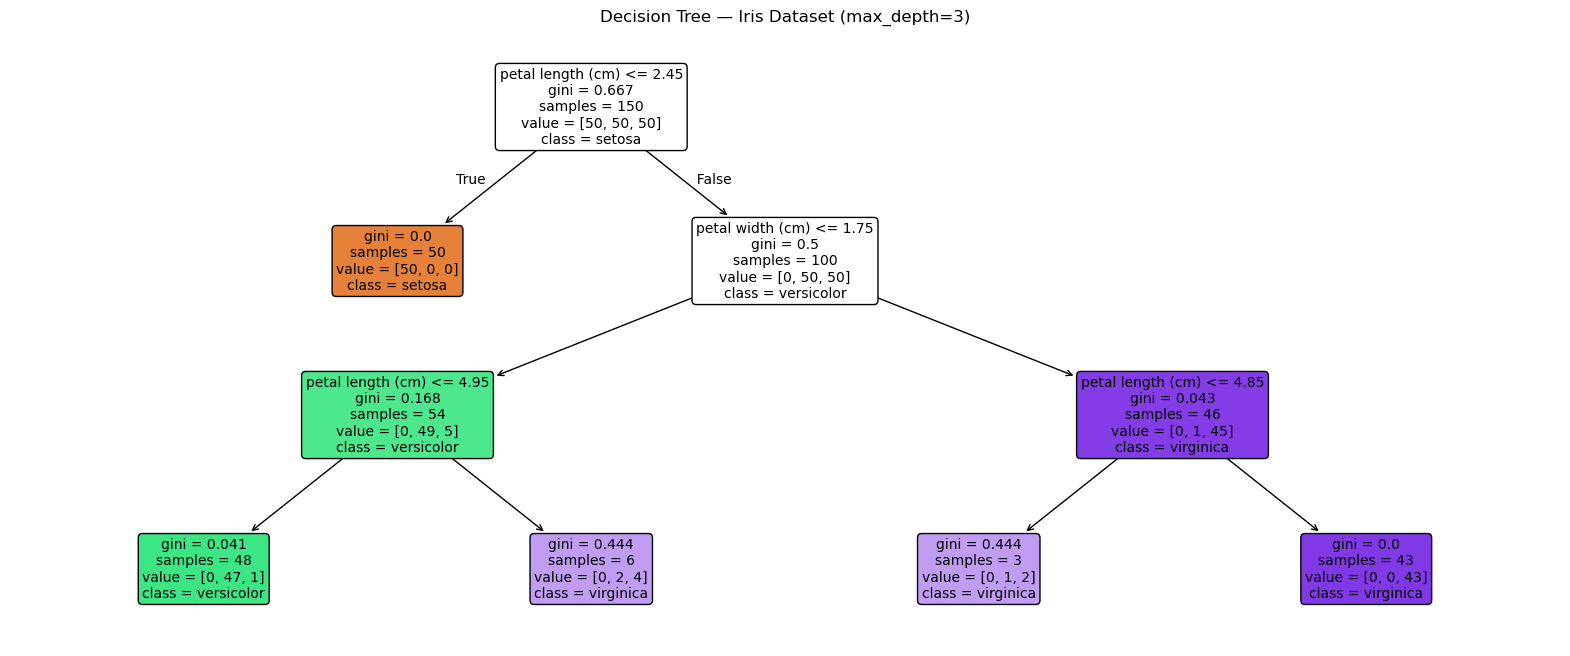

Train accuracy: 0.9733


In [3]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_iris

# load iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# fit shallow tree - max depth 3
tree = DecisionTreeClassifier(max_depth=3, random_state = 42)
tree.fit(X,y)

# visualize 
plt.figure(figsize=(20,8))
plot_tree(tree,
          feature_names=iris.feature_names, 
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree — Iris Dataset (max_depth=3)')
plt.savefig('decision_tree_iris.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Train accuracy: {tree.score(X, y):.4f}")

# Trace one sample through the tree manually:

In [4]:
# pick one sample and trace it
sample = X[0].reshape(1, -1)
print("Sample features:")
for name, val in zip(iris.feature_names, X[0]):
    print(f"  {name}: {val}")

print(f"\nActual class    : {iris.target_names[y[0]]}")
print(f"Predicted class : {iris.target_names[tree.predict(sample)[0]]}")
print(f"Probabilities   : {tree.predict_proba(sample)[0]}")

Sample features:
  sepal length (cm): 5.1
  sepal width (cm): 3.5
  petal length (cm): 1.4
  petal width (cm): 0.2

Actual class    : setosa
Predicted class : setosa
Probabilities   : [1. 0. 0.]
